### C3M10: Creating Data Visualizations for EDA

REGRESSION UNUSUAL POINTS.  We start with a quick simulation to see the kind of things that can happen

In [1]:
data1 <- matrix(c(1, 0, 0, 1, 1, 2, 2, 1, 10 , 10), byrow = T, ncol = 2)
data1

1,0
0,1
1,2
2,1
10,10


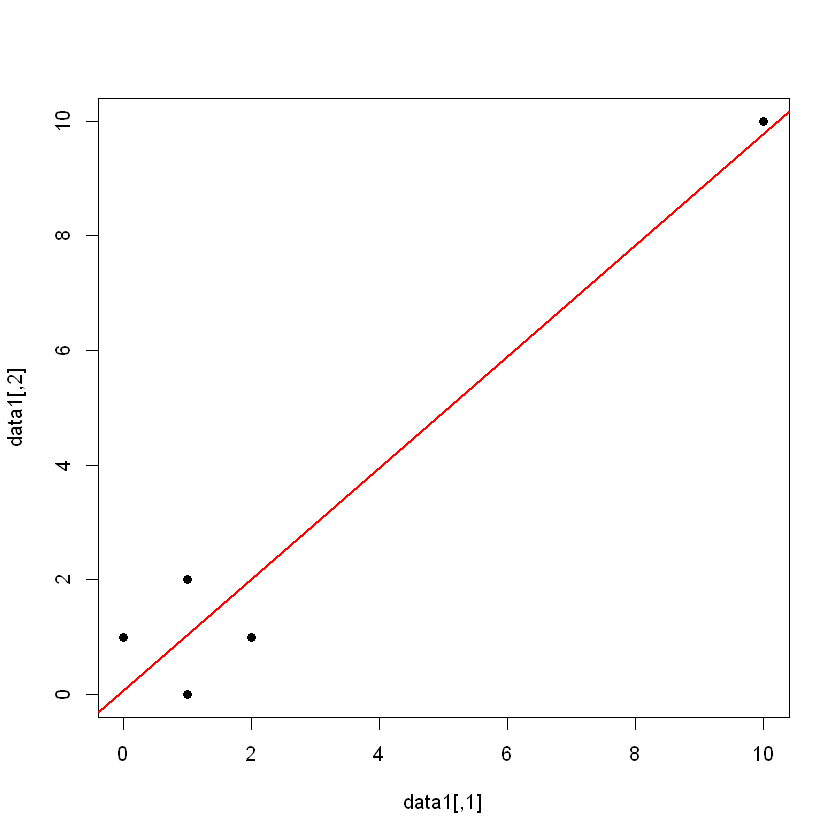

In [2]:
plot(data1, pch = 19)

#what kind of point is 10,10?
mod1 <- lm(data1[, 2] ~ data1[, 1])
abline(mod1$coef, col = 'red', lwd = 2)

In [3]:
#Get summary information for the model
#Notice the large R-squared value
summary(mod1)


Call:
lm(formula = data1[, 2] ~ data1[, 1])

Residuals:
      1       2       3       4       5 
-1.0539  0.9162  0.9461 -1.0240  0.2156 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)   
(Intercept)  0.08383    0.64562   0.130  0.90490   
data1[, 1]   0.97006    0.14022   6.918  0.00619 **
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 1.146 on 3 degrees of freedom
Multiple R-squared:  0.941,	Adjusted R-squared:  0.9214 
F-statistic: 47.86 on 1 and 3 DF,  p-value: 0.006191


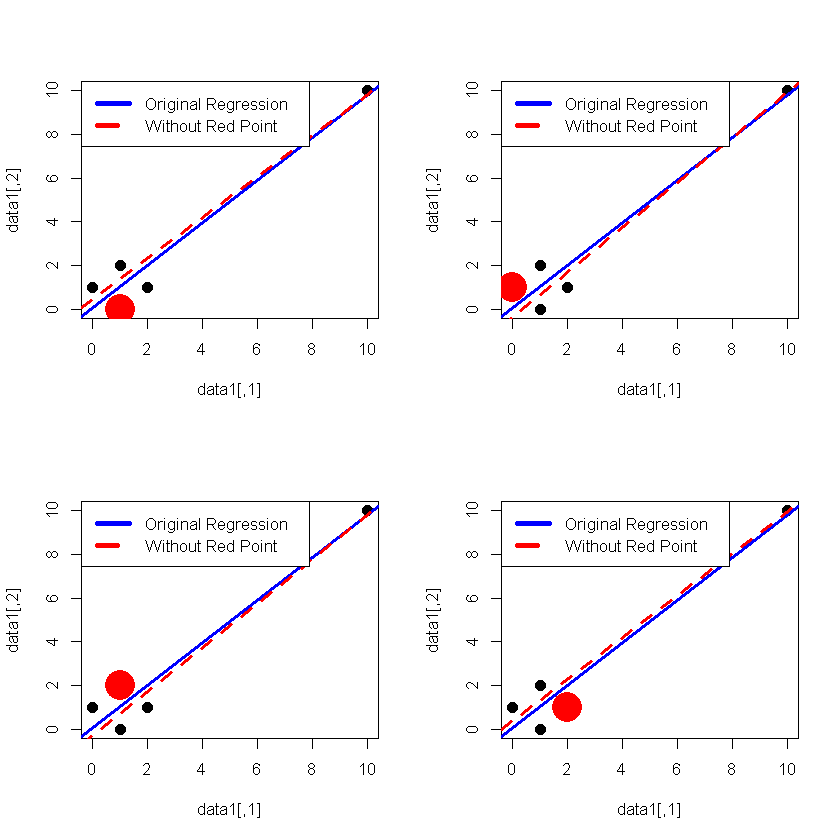

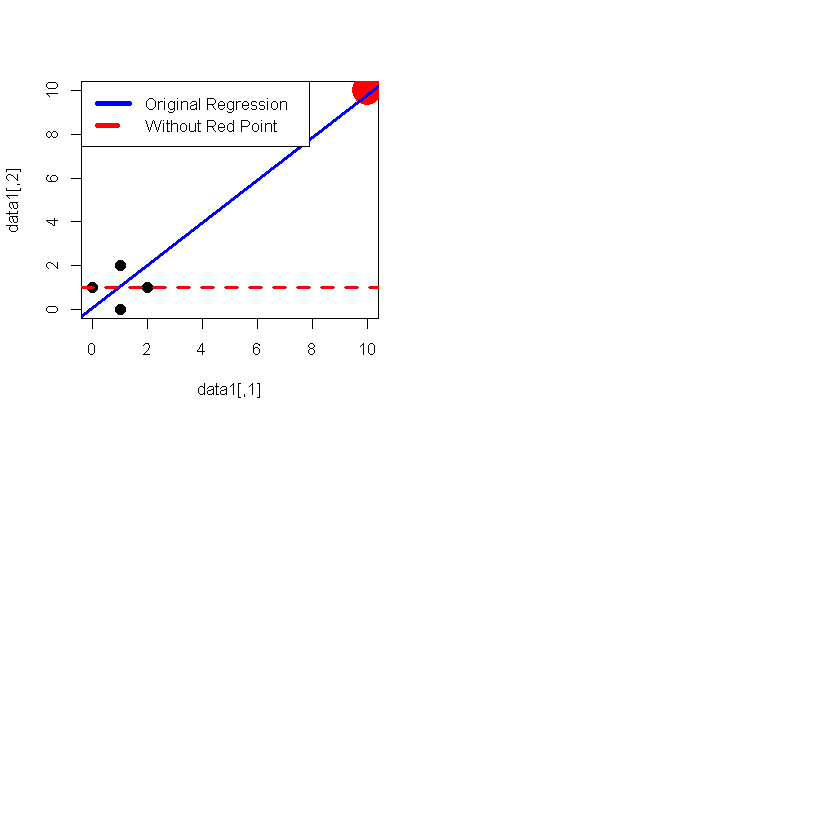

In [4]:
#Let's run a simulation to see how much the line changes without each point
par(mfrow = c(2, 2))
for (i in 1:5){
  mod2 <- lm(data1[-i, 2] ~ data1[-i, 1])
  plot(data1, pch = 19, cex = 1.5)
  points(data1[i, 1], data1[i, 2], pch = 19, col = 'red', cex = 4)
  abline(mod1$coef, col = 'blue', lwd = 3)
  abline(mod2$coef, col = 'red', lwd = 3, lty = 2)
  legend("topleft", c("Original Regression","Without Red Point"), col = c("blue", "red"), lwd = 4, lty = c(1,2))
}


In [5]:
#finally see how R-squared changes without the influential point
summary(mod1)
mod2 <- lm(data1[-5, 2] ~ data1[-5, 1])
summary(mod2)


Call:
lm(formula = data1[, 2] ~ data1[, 1])

Residuals:
      1       2       3       4       5 
-1.0539  0.9162  0.9461 -1.0240  0.2156 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)   
(Intercept)  0.08383    0.64562   0.130  0.90490   
data1[, 1]   0.97006    0.14022   6.918  0.00619 **
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 1.146 on 3 degrees of freedom
Multiple R-squared:  0.941,	Adjusted R-squared:  0.9214 
F-statistic: 47.86 on 1 and 3 DF,  p-value: 0.006191



Call:
lm(formula = data1[-5, 2] ~ data1[-5, 1])

Residuals:
         1          2          3          4 
-1.000e+00  0.000e+00  1.000e+00  5.551e-17 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)
(Intercept)   1.000e+00  8.660e-01   1.155    0.368
data1[-5, 1] -3.925e-17  7.071e-01   0.000    1.000

Residual standard error: 1 on 2 degrees of freedom
Multiple R-squared:  2.465e-32,	Adjusted R-squared:   -0.5 
F-statistic: 4.93e-32 on 1 and 2 DF,  p-value: 1


Body Brain Weights of Mammals.  We will look at this data on the log scale. Our goal now is to fit a model and examine residual plots.

In [6]:
#get data
BodyBrain <- read.csv("https://raw.githubusercontent.com/jreuning/YSE_EDA_data/refs/heads/main/BodyBrainMammals.csv", header = T)


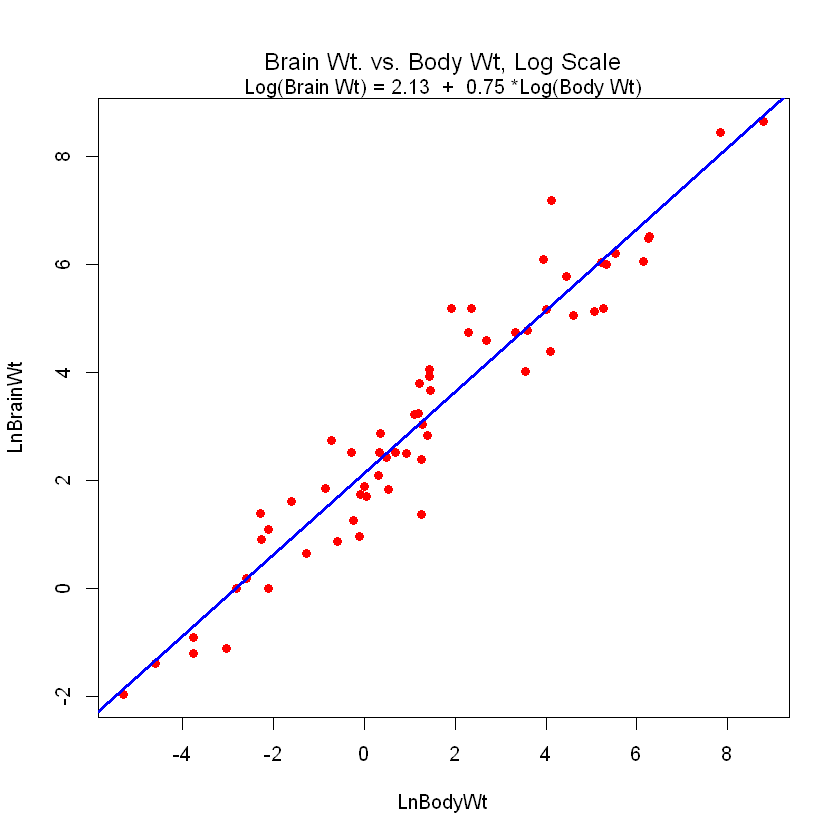

In [7]:
#Fitted Line Plot
lm1 <- lm(LnBrainWt ~ LnBodyWt, data = BodyBrain)
plot(LnBrainWt ~ LnBodyWt, 
     data = BodyBrain, 
     col = 'red', 
     pch = 19)

abline(lm1$coef, col = "blue", lwd = 3)
mtext("Brain Wt. vs. Body Wt, Log Scale", line = 1, cex = 1.2)
mtext(paste("Log(Brain Wt) =", round(lm1$coef[1], 2)," + ", round(lm1$coef[2], 2), "*Log(Body Wt)"), line = 0)

RESIDUAL PLOTS: We look are normal quantile plots of residuals and plots of fits vs. residuals.
I made a function to produce both of these plots called myResPlots.  There are other ways to do this.

In [8]:
#Residual plots
#Load car library which has a cool function qqp for making quantile plots.
library(car)
myResPlots <- function(model, label){
  
  #Normal quantile plot of studentized residuals
  qqp(model$resid, pch = 19, main = paste("QQ Plot of Residuals,", label))
  #plot of fitted vs. studentized residuals
  plot(model$resid ~ model$fitted.values, pch = 19, col = 'red', xlab = "Fitted Values", ylab = "Residuals",
     main = paste("Fits vs. Residuals,", label), cex.main = 1)
  abline(h = 0, lwd = 3)
  #abline(h = c(2,-2), lty = 2, lwd = 2, col="blue")
  #abline(h = c(3,-3), lty = 2, lwd = 2, col="green")

}


Loading required package: carData



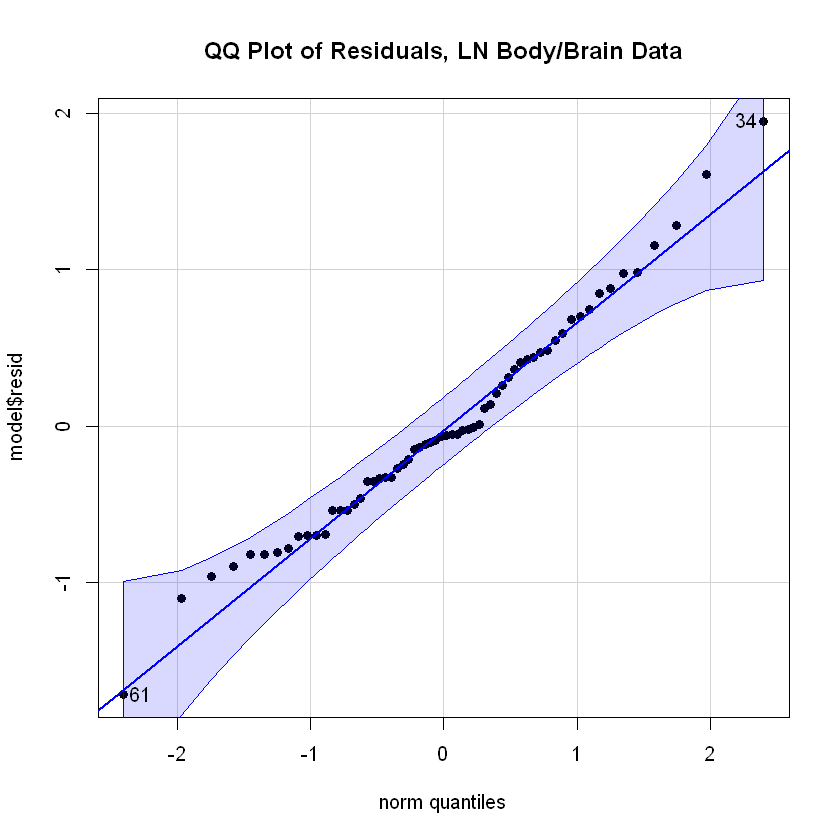

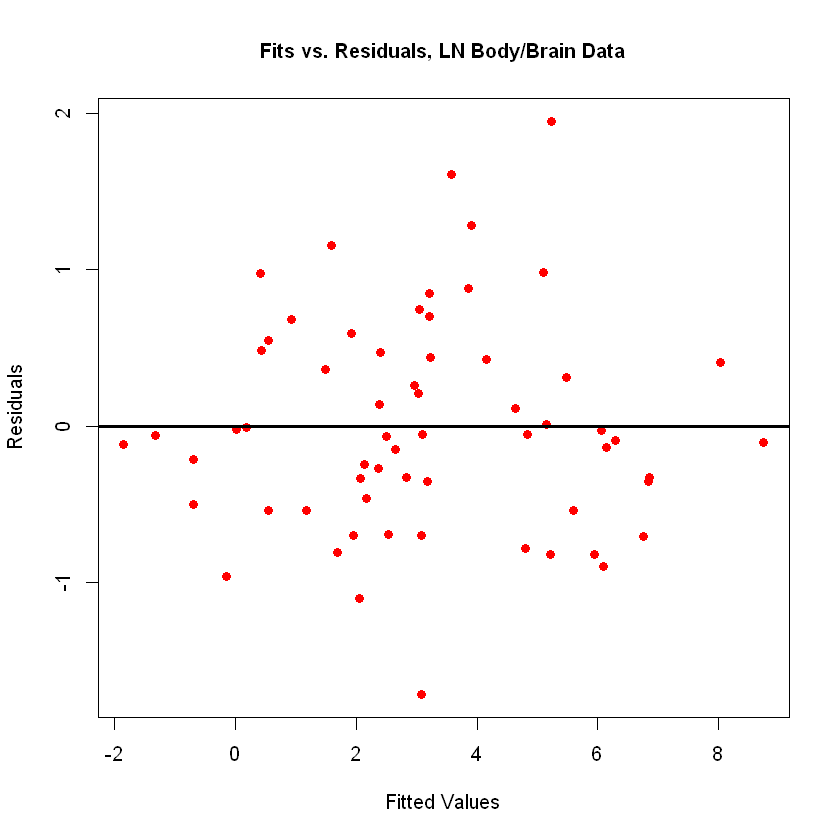

In [9]:
#Residual plots for lnBrain and lnBody data
myResPlots(lm1, "LN Body/Brain Data")
#Everything looks good!

WORLD BANK DATA.  We look at several regression examples

In [10]:
#To same time, I wrote a function to make fitted line plots
fitPlot <- function(x, y, xlab, ylab){
  plot(x, y,
       pch = 19, 
       cex.main = 1, 
       xlab = xlab,
       ylab = ylab,
       main = paste("Scatterplot of", xlab, "vs", ylab),
       col = 'red')
  mod1 <- lm(y ~ x)
  abline(mod1$coef, col = "blue", lwd = 3)
  mtext(paste(ylab,"=", round(mod1$coef[1], 4), "+", round(mod1$coef[2], 4), "*", xlab), line = 0)
}

In [11]:
#Get the World Bank Data
#World Bank data, 2016 version
WB <- read.csv("https://raw.githubusercontent.com/jreuning/sds230_data/refs/heads/main/WB.2016.csv", header = T, as.is = T)
names(WB)

[1] "Country"       "Code"          "Population"    "Rural"        
 [5] "GNI"           "IncomeTop10"   "Imports"       "Exports"      
 [9] "Military"      "Cell"          "Fertility66"   "Fertility16"  
[13] "Measles"       "InfMort"       "LifeExp"       "PM2.5"        
[17] "Diesel"        "CO2"           "EnergyUse"     "FossilPct"    
[21] "Forest94"      "Forest14"      "Deforestation" "GunTotal"     
[25] "GunHomicide"   "GunSuicide"    "GunUnint"      "GunUndet"     
[29] "GunsPer100"

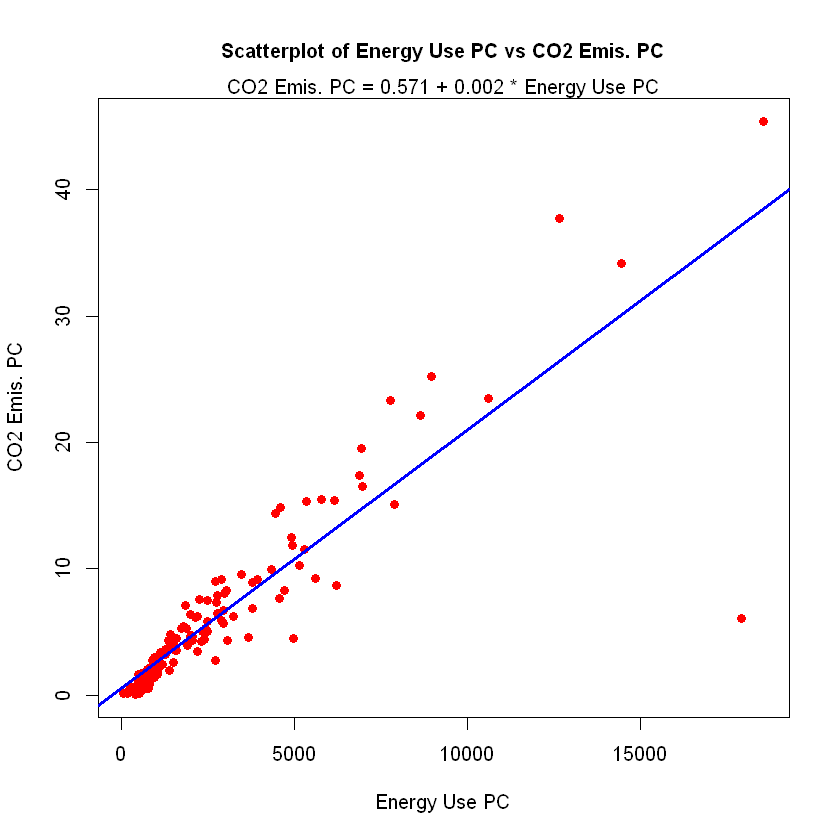

In [12]:
#Energy Use per capita as a predictor of CO2 Emissions per capita
fitPlot(WB$EnergyUse, WB$CO2, "Energy Use PC", "CO2 Emis. PC")

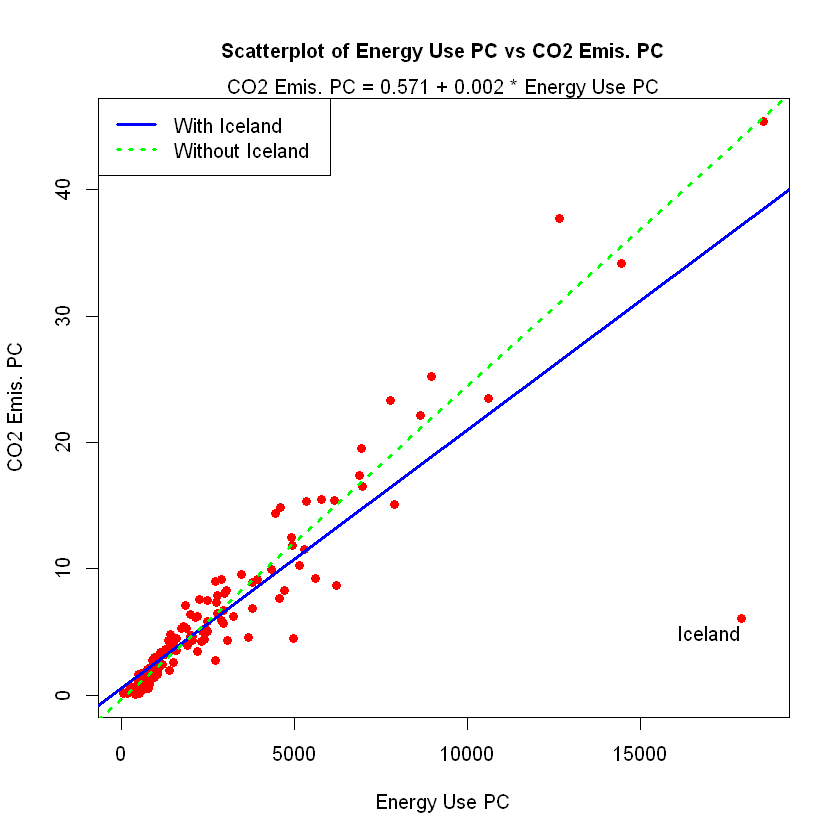

In [13]:
#If you are curious, here is code to add a line without Iceland and to identify this point
fitPlot(WB$EnergyUse, WB$CO2, "Energy Use PC", "CO2 Emis. PC")
mod2 <- lm(WB$CO2[!(WB$EnergyUse > 15000 & WB$CO2 < 10)] ~ WB$EnergyUse[!(WB$EnergyUse > 15000 & WB$CO2 < 10)] )
abline(mod2$coef, col = "green", lwd = 3, lty = 3)
legend("topleft", c("With Iceland", "Without Iceland"),col = c("blue", "green"), lwd = 3, lty = c(1, 3))
text(17000, 5, "Iceland")

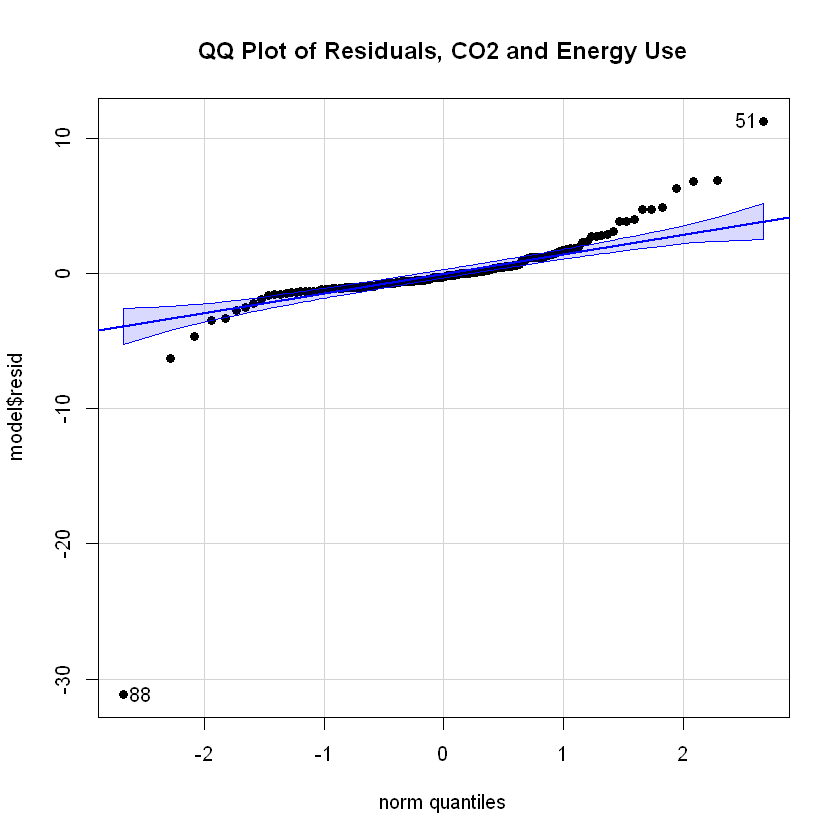

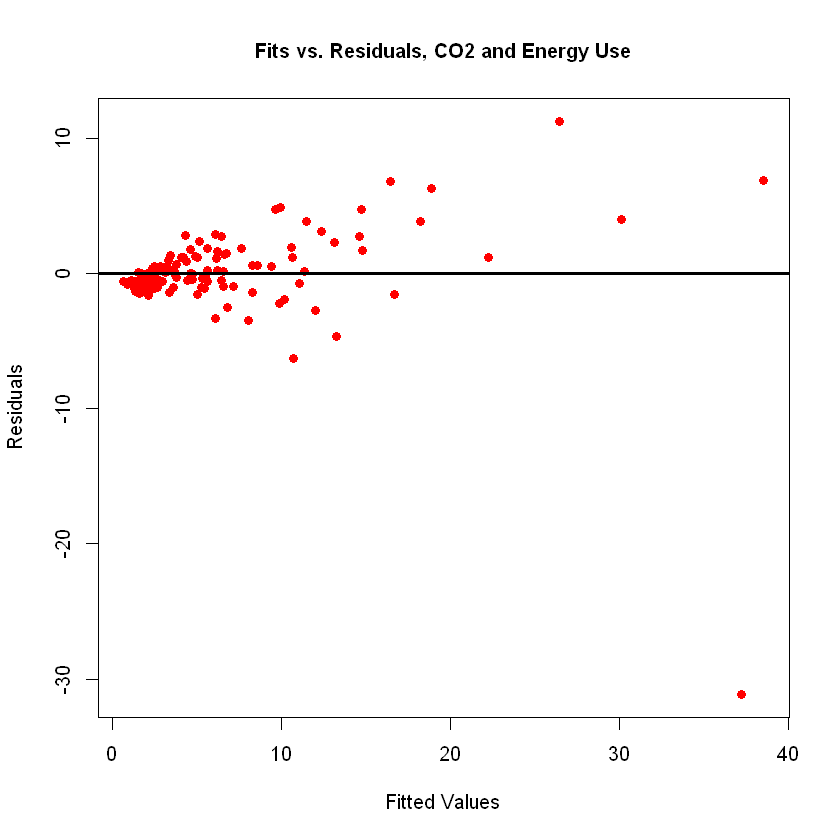

In [14]:
#Lets look at residual plots for the original model that includes Iceland
mod2 <- lm(CO2 ~ EnergyUse, data = WB)
myResPlots(mod2, "CO2 and Energy Use")


We can see that Iceland is an outlier and that our residuals aren't exactly normally distributed.  The plot of fits vs residuals is also not exactly 'random scatter' with no trends.  We try this on the log scale for both variables.

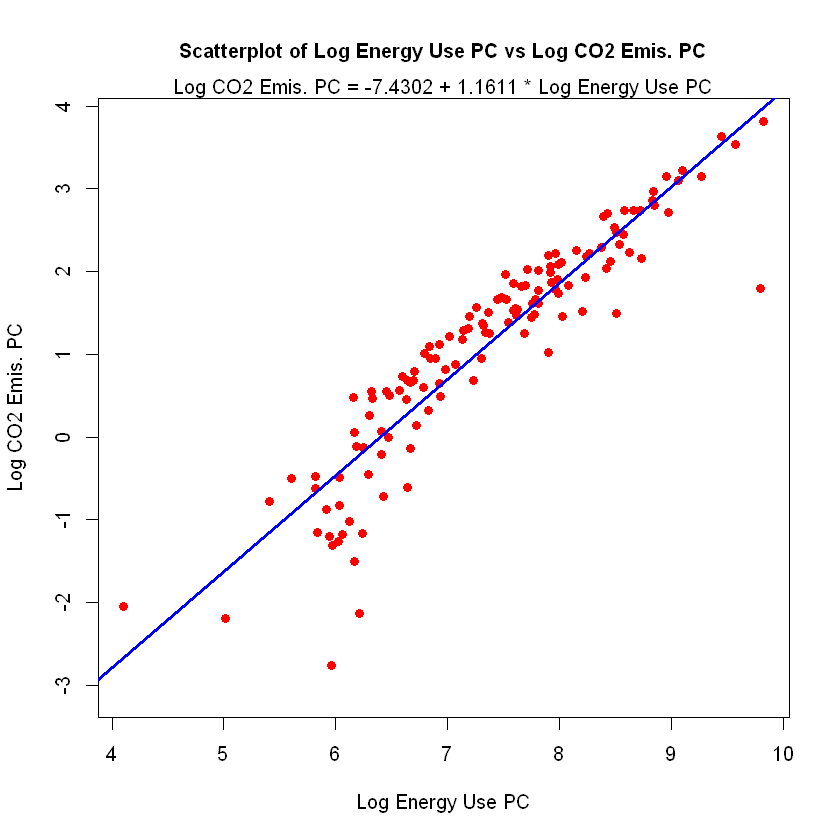

In [15]:
fitPlot(log(WB$EnergyUse), log(WB$CO2), "Log Energy Use PC", "Log CO2 Emis. PC")

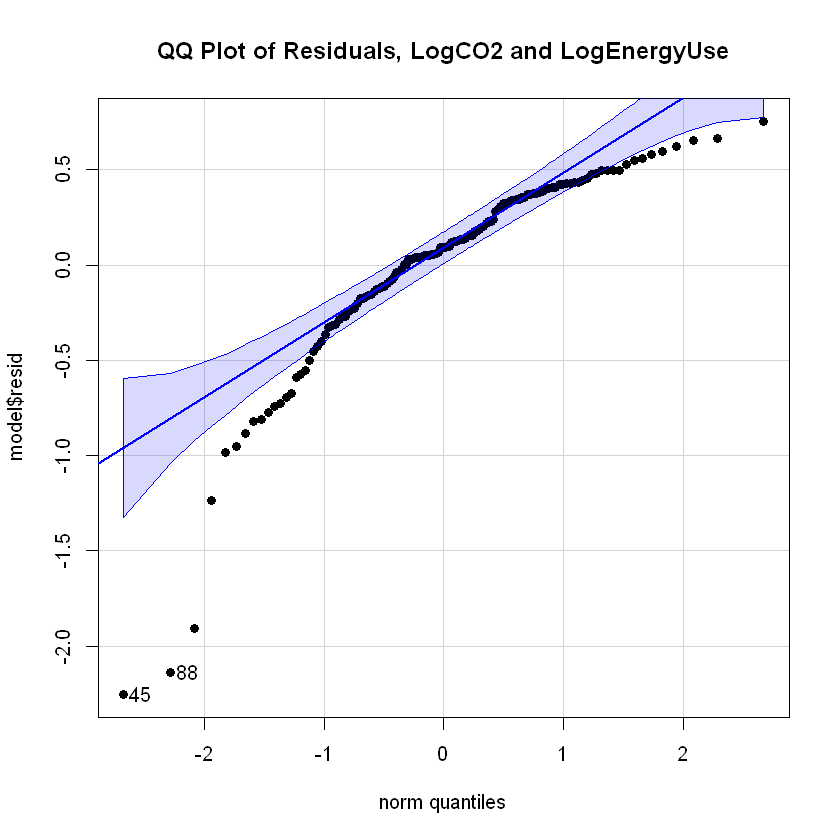

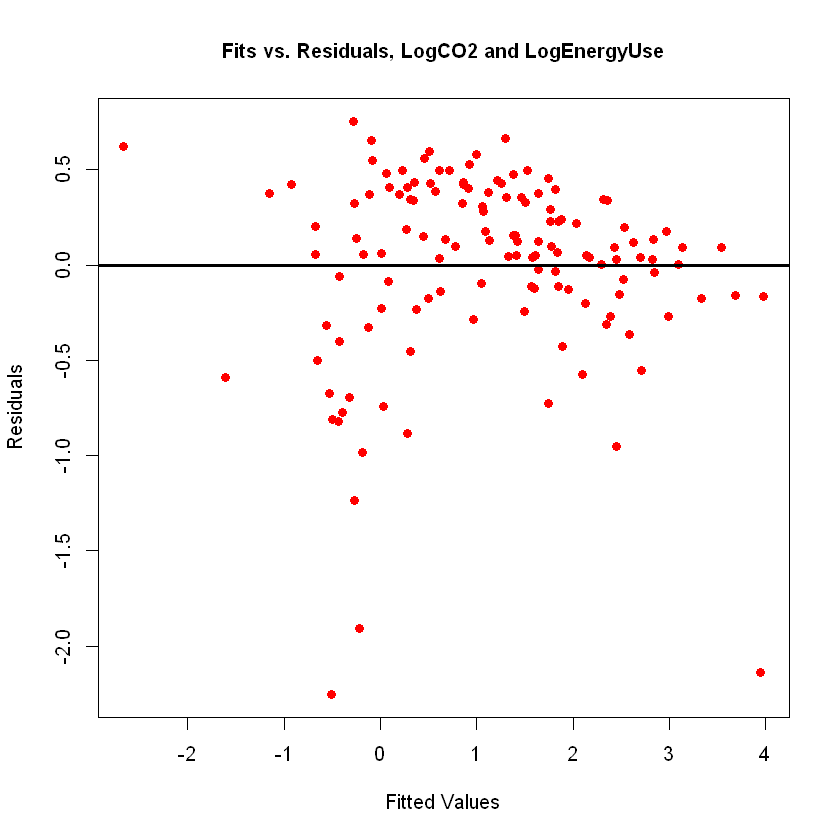

In [16]:
mod3 <- lm(log(WB$CO2) ~ log(WB$EnergyUse))
myResPlots(mod3, "LogCO2 and LogEnergyUse")

In [0]:
Still not perfect, but better.  More investigation required!
At this point, try fitting some regression models with other pairs of variables!